In [1]:
import pandas as pd

df = pd.read_parquet("../outputs/user_anomaly_scores.parquet")

df.head()

,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
0,nnImk681KaRqUVHlSfZjGQ,3.895792,0.388778,0.046092,499,0.069104,7221.0,4214.0,0.237602,1,1
1,6s-g2vFu12OemhiK3FJuOQ,3.653120,0.111756,0.007257,689,0.098288,7010.0,4449.0,0.237338,1,2
2,0G-QF457q_0Z_jKqh6xWiA,4.164306,0.402266,0.005666,353,0.053339,6618.0,6234.0,0.235640,1,3
3,cufhYFdyrUAt4SWe-m0grQ,3.904139,0.161220,0.006536,459,0.068950,6657.0,6232.0,0.235565,1,4
4,bJ5FtCtZX3ZZacz2_2PJjA,4.069281,0.326797,0.011765,765,0.111500,6861.0,1538.0,0.234197,1,5


In [2]:
# Count total rows vs unique IDs
total_rows = len(df)
unique_ids = df['user_id'].nunique()

print(f"Total rows in file: {total_rows:,}")
print(f"Unique User IDs:    {unique_ids:,}")

# Check if there are any duplicates
if total_rows == unique_ids:
    print("Verification: Every row represents a unique user.")
else:
    print(f"Warning: There are {total_rows - unique_ids} duplicate user IDs.")

Total rows in file: 1,445,984
Unique User IDs:    1,445,984
Verification: Every row represents a unique user.


In [3]:
# Check the count of NaN values for each column
missing_counts = df.isna().sum()
missing_percentages = (df.isna().mean() * 100).round(6)
# Create a summary table
missing_summary = pd.DataFrame({
    'NaN Count': missing_counts,
    'Percentage (%)': missing_percentages
})

print(missing_summary)

                    NaN Count  Percentage (%)
user_id                     0             0.0
avg_stars_given             0             0.0
pct_5_star_reviews          0             0.0
pct_1_star_reviews          0             0.0
review_count                0             0.0
reviews_per_day             0             0.0
account_age_days            0             0.0
num_friends                 0             0.0
anomaly_score               0             0.0
is_anomaly                  0             0.0
anomaly_rank                0             0.0


In [4]:
# Filter for the rows where account_age_days or num_friends is missing
nan_users = df[df['account_age_days'].isna() | df['num_friends'].isna()]

# Display the user_ids and their scores
print(f"Found {len(nan_users)} users with missing data:")
print(nan_users[['user_id', 'review_count', 'account_age_days', 'anomaly_score']])

# List of the IDs
list_of_ids = nan_users['user_id'].tolist()
print("\nUser IDs for manual checking:")
print(list_of_ids)

Found 0 users with missing data:
Empty DataFrame
Columns: [user_id, review_count, account_age_days, anomaly_score]
Index: []

User IDs for manual checking:
[]


In [5]:
# Showing which is an anomaly
df[df["is_anomaly"] == 1].head(20)

,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
0,nnImk681KaRqUVHlSfZjGQ,3.895792,0.388778,0.046092,499,0.069104,7221.0,4214.0,0.237602,1,1
1,6s-g2vFu12OemhiK3FJuOQ,3.653120,0.111756,0.007257,689,0.098288,7010.0,4449.0,0.237338,1,2
2,0G-QF457q_0Z_jKqh6xWiA,4.164306,0.402266,0.005666,353,0.053339,6618.0,6234.0,0.235640,1,3
3,cufhYFdyrUAt4SWe-m0grQ,3.904139,0.161220,0.006536,459,0.068950,6657.0,6232.0,0.235565,1,4
4,bJ5FtCtZX3ZZacz2_2PJjA,4.069281,0.326797,0.011765,765,0.111500,6861.0,1538.0,0.234197,1,5
5,_BcWyKQL16ndpBdggh2kNA,3.542840,0.107981,0.025822,1704,0.260550,6540.0,3708.0,0.233424,1,6
6,ET8n-r7glWYqZhuR6GcdNw,3.971154,0.298951,0.006119,1144,0.173281,6602.0,5958.0,0.233240,1,7
7,KDewJBJknfWvQyHHFNbfdg,4.149038,0.379808,0.009615,208,0.030842,6744.0,3964.0,0.232767,1,8
8,djxnI8Ux8ZYQJhiOQkrRhA,3.789855,0.202899,0.003623,276,0.042073,6560.0,8858.0,0.232168,1,9
9,y8aWXOimQ9ZgUgZ6q--nCQ,3.868996,0.344978,0.056769,229,0.033956,6744.0,1716.0,0.231482,1,10


In [6]:
df[df["is_anomaly"] == 1][[
    "avg_stars_given",
    "pct_5_star_reviews",
    "review_count",
    "reviews_per_day",
    "num_friends"
]].describe()

,avg_stars_given,pct_5_star_reviews,review_count,reviews_per_day,num_friends
count,72300.000000,72300.000000,72300.000000,72300.000000,72300.000000
mean,3.280927,0.344954,23.817566,0.005263,306.553237
std,1.218441,0.294620,39.318518,0.007943,520.477115
min,1.000000,0.000000,1.000000,0.000127,0.000000
25%,2.457143,0.089888,4.000000,0.000988,9.000000
50%,3.636364,0.300000,14.000000,0.003433,120.000000
75%,4.178571,0.524590,28.000000,0.006287,430.000000
max,5.000000,1.000000,1704.000000,0.269386,14995.000000


In [7]:
top_anomalies = (
    df[df["is_anomaly"] == 1]
    .sort_values("anomaly_score", ascending=False)
)
# Find potential bots
# Users with 0 friends and are in anomaly list
bots = top_anomalies[
    (top_anomalies['num_friends'] == 0) & 
    (top_anomalies['is_anomaly'] == 1)
].head(10)

# Find "Review Bombers" 
# (Using 0.1 instead based on max of 0.269)
bombers = top_anomalies[
    (top_anomalies['reviews_per_day'] > 0.1) & 
    (top_anomalies['is_anomaly'] == 1)
].head(10)

print("0 Friends + Anomalous (bots)")
display(bots)

print("\n High Velocity + Anomalous (Review Bombers)")
display(bombers)

0 Friends + Anomalous (bots)


,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
619,R-c5M0iJkMxxTxIqTQQZ8w,2.836272,0.015113,0.040302,397,0.064229,6181.0,0.0,0.183967,1,620
667,QG-5Xa3R9_TmDDL4g9BiRA,1.892857,0.190476,0.690476,84,0.033830,2483.0,0.0,0.182709,1,668
756,Z6gS-BqSWT35vY1XtGLLeQ,1.779412,0.088235,0.573529,68,0.027857,2441.0,0.0,0.180771,1,757
770,sGCCjnXG_3SoUmqwyswEfA,2.118519,0.125926,0.540741,135,0.027185,4966.0,0.0,0.180501,1,771
775,LM7ebdJWVsmx6hGAo6qa5A,2.827160,0.111111,0.197531,162,0.029818,5433.0,0.0,0.180341,1,776
792,S84rIUvqA2S0gtpmoK3k_w,3.391705,0.156682,0.046083,217,0.036017,6025.0,0.0,0.180068,1,793
819,hPtHL1JLtYIIrCDhrjUBaQ,2.932886,0.231544,0.265101,298,0.056026,5319.0,0.0,0.179459,1,820
1044,K8_kxQ6IQ_4O8RXioJd8uQ,2.797386,0.104575,0.183007,153,0.034537,4430.0,0.0,0.175219,1,1045
1300,bIw6zquJOoUyUaidD85q4Q,4.791667,0.875000,0.013889,72,0.043663,1649.0,0.0,0.171382,1,1301
1306,OQaneFUkS1rJJvqfUzjb6g,3.321212,0.345455,0.230303,165,0.036424,4530.0,0.0,0.171276,1,1307



 High Velocity + Anomalous (Review Bombers)


,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
4,bJ5FtCtZX3ZZacz2_2PJjA,4.069281,0.326797,0.011765,765,0.111500,6861.0,1538.0,0.234197,1,5
5,_BcWyKQL16ndpBdggh2kNA,3.542840,0.107981,0.025822,1704,0.260550,6540.0,3708.0,0.233424,1,6
6,ET8n-r7glWYqZhuR6GcdNw,3.971154,0.298951,0.006119,1144,0.173281,6602.0,5958.0,0.233240,1,7
19,vHc-UrI9yfL_pnnc6nJtyQ,4.383148,0.556439,0.001590,629,0.110700,5682.0,6481.0,0.229011,1,20
21,-kLVfaJytOJY2-QdQoCcNQ,4.241329,0.404624,0.001445,692,0.139883,4947.0,3573.0,0.228608,1,22
26,pou3BbKsIozfH50rxmnMew,4.197105,0.419822,0.005568,898,0.172097,5218.0,4024.0,0.227845,1,27
35,-G7Zkl1wIWBBmD0KRy_sCw,3.589823,0.147263,0.017733,1297,0.265888,4878.0,1787.0,0.225210,1,36
40,h7p-GuaHFGsiKCF4g6Bjqg,3.535792,0.104121,0.006508,461,0.103155,4469.0,2729.0,0.224091,1,41
46,WwulXySQN8t2hwqH_yWurA,4.453744,0.555066,0.004405,454,0.109424,4149.0,6896.0,0.223122,1,47
55,ouODopBKF3AqfCkuQEnrDg,3.571130,0.116109,0.026151,956,0.163140,5860.0,1141.0,0.221966,1,56


In [8]:
# all anomalies Check
anomalies = df[df["is_anomaly"] == 1]

print("all anomalies:", len(anomalies))
print("zero-friend anomalies (all):", ((anomalies["num_friends"] == 0)).sum())

# top 500 anomalies only
top_anomalies = anomalies.sort_values("anomaly_score", ascending=False).head(500)
print("zero-friend anomalies (top 500):", ((top_anomalies["num_friends"] == 0)).sum())

all anomalies: 72300
zero-friend anomalies (all): 9732
zero-friend anomalies (top 500): 0


In [9]:
# Calculate correlation between all numeric columns
correlation_matrix = df[["anomaly_score", "num_friends", "reviews_per_day", "review_count"]].corr()

# Specifically look at the relationship with anomaly_score
print("Correlation with Anomaly Score:")
print(correlation_matrix["anomaly_score"].sort_values(ascending=False))

Correlation with Anomaly Score:
anomaly_score      1.000000
reviews_per_day    0.501998
review_count       0.471799
num_friends        0.388648
Name: anomaly_score, dtype: float64


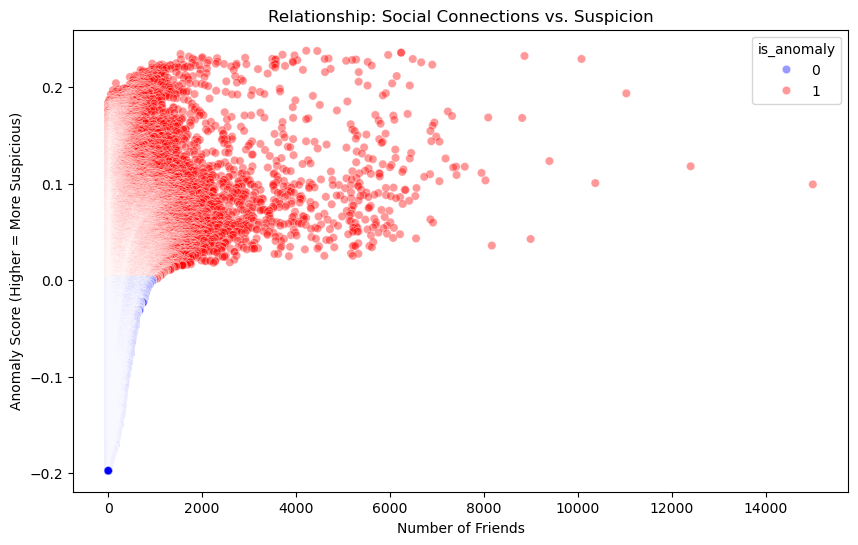

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Use a scatter plot to see where the anomalies (red) sit compared to normal users (blue)
sns.scatterplot(
    data=df, 
    x="num_friends", 
    y="anomaly_score", 
    hue="is_anomaly", 
    palette={0: "blue", 1: "red"},
    alpha=0.4
)

plt.title("Relationship: Social Connections vs. Suspicion")
plt.xlabel("Number of Friends")
plt.ylabel("Anomaly Score (Higher = More Suspicious)")
plt.show()

In [11]:
anomalies_only = df[df["is_anomaly"] == 1]

# Define the high-rating group
high_rating_anomalies = (
    anomalies_only[anomalies_only["avg_stars_given"] >= 4.5]
    .sort_values("anomaly_score", ascending=False)
)

# Define the low-rating group
low_rating_anomalies = (
    anomalies_only[anomalies_only["avg_stars_given"] <= 1.5]
    .sort_values("anomaly_score", ascending=False)
)

In [12]:
# Display preview including review_count
print("\n--- HIGH-RATING ANOMALOUS USERS PREVIEW ---")
display(
    high_rating_anomalies[
        ["user_id", "review_count", "avg_stars_given", "reviews_per_day", "num_friends"]
    ].head(10) # Look at 10 instead of 5 to see the pattern
)

print("\n--- LOW-RATING ANOMALOUS USERS PREVIEW ---")
display(
    low_rating_anomalies[
        ["user_id", "review_count", "avg_stars_given", "reviews_per_day", "num_friends"]
    ].head(10)
)


--- HIGH-RATING ANOMALOUS USERS PREVIEW ---


,user_id,review_count,avg_stars_given,reviews_per_day,num_friends
86,4DyMRBKrokax6d8LCI3GAw,106,4.613208,0.015351,4143.0
87,wYlael7ejt4I3vjaXmpGnA,240,4.545833,0.066983,2671.0
117,tuoDDqTDCB-lDgelvMrp5Q,329,4.571429,0.089208,1139.0
181,mARd7AyQ_FGRRfgwTTOY6w,104,4.644231,0.019671,1231.0
183,TJ8Hawan8jDIZHS7AAZJwg,139,4.582734,0.030113,931.0
193,Glq_5Fn45I4HkNqRhfuDkw,126,4.571429,0.022818,1156.0
197,Y-fPeP9dmciMYg83esNSWw,92,4.500000,0.027512,1147.0
222,AVyU4MC9ucdgCFRaLNpePQ,337,4.661721,0.072489,741.0
231,d279EdAqiPeDsHW4Ichxdg,60,4.716667,0.019894,1420.0
263,DQ6jWIWjzVRbS_5QA-FMUg,90,4.700000,0.034575,645.0



--- LOW-RATING ANOMALOUS USERS PREVIEW ---


,user_id,review_count,avg_stars_given,reviews_per_day,num_friends
821,oDlFUW7dJmQBP-czr_tVqg,82,1.292683,0.027554,19.0
983,wtkM3aDAJZyPo5qdG8ATrw,45,1.444444,0.024523,1.0
2045,D1LD4rsQi1W1iR7zb_Neaw,33,1.363636,0.008569,327.0
2486,YpZByJIgbMsTvPdOjURFsg,55,1.490909,0.010097,4.0
4333,bWyZZxJtbngmNGhEQ1isbA,1,1.000000,0.000146,1904.0
4402,F61ElwwUz8vUVDp5tg6H0A,1,1.000000,0.000144,1461.0
4408,vXbvuLRXNqp_wimQHNbA4w,46,1.304348,0.009459,1.0
4475,vZ-BCS4GCCLZwHXP3nezjw,10,1.400000,0.001834,965.0
4800,DdrP5ng377vmc8vEePLcDw,48,1.270833,0.010721,0.0
5404,0elvzLJIZdIJssahAkasBA,5,1.000000,0.001353,1058.0


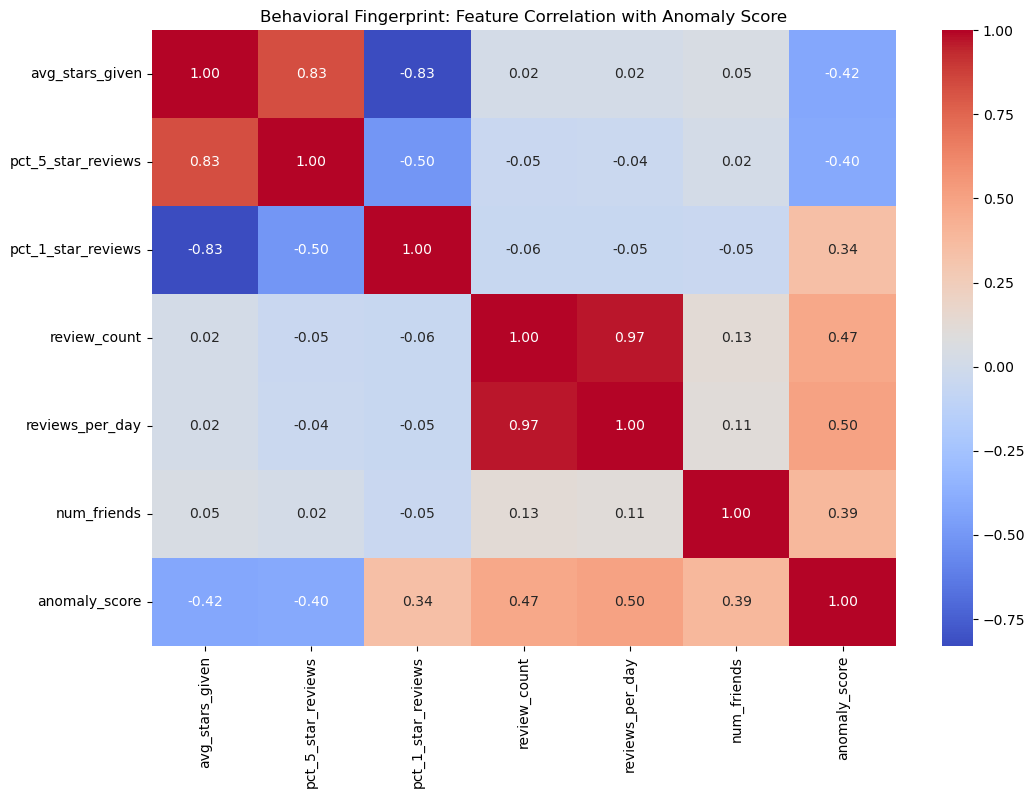

In [13]:
# Features used in your model
features = ["avg_stars_given", "pct_5_star_reviews", "pct_1_star_reviews", 
            "review_count", "reviews_per_day", "num_friends", "anomaly_score"]

plt.figure(figsize=(12, 8))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Behavioral Fingerprint: Feature Correlation with Anomaly Score")
plt.show()

In [14]:
#  top 5 users ranked as most anomalous, along with key behavioral features
df[df["anomaly_rank"] <= 5][["user_id", "review_count", "reviews_per_day", "num_friends", "anomaly_score"]]

,user_id,review_count,reviews_per_day,num_friends,anomaly_score
0,nnImk681KaRqUVHlSfZjGQ,499,0.069104,4214.0,0.237602
1,6s-g2vFu12OemhiK3FJuOQ,689,0.098288,4449.0,0.237338
2,0G-QF457q_0Z_jKqh6xWiA,353,0.053339,6234.0,0.235640
3,cufhYFdyrUAt4SWe-m0grQ,459,0.068950,6232.0,0.235565
4,bJ5FtCtZX3ZZacz2_2PJjA,765,0.111500,1538.0,0.234197


In [15]:
# Looking for extreme suspicious behavior
# Finds users who are flagged as anomalies AND give almost all 5-star OR all 1-star reviews
suspicious_extreme = df[
    (df["is_anomaly"] == 1) &
    (
        (df["pct_5_star_reviews"] > 0.95) |
        (df["pct_1_star_reviews"] > 0.95)
    )
]
suspicious_extreme = suspicious_extreme.sort_values("anomaly_score", ascending=False)
suspicious_extreme.head(10)

,user_id,avg_stars_given,pct_5_star_reviews,pct_1_star_reviews,review_count,reviews_per_day,account_age_days,num_friends,anomaly_score,is_anomaly,anomaly_rank
902,XmBm3C-Y7TKHuMoEMO5AtQ,4.978723,0.978723,0.000000,94,0.013657,6883.0,440.0,0.177652,1,903
1744,rHGnUvQBIPPw-BYxQL3zGg,5.000000,1.000000,0.000000,73,0.028361,2574.0,298.0,0.165862,1,1745
2182,7NHf3QgyGlZ_9pwdWLFdhA,5.000000,1.000000,0.000000,162,0.041138,3938.0,133.0,0.160917,1,2183
2308,QKPkbuVIbN1v9gj4qpQAnA,4.900000,0.966667,0.000000,30,0.006420,4673.0,1217.0,0.159456,1,2309
2664,wF_CbmxgMKnC_ZnPcPCFqw,4.846154,0.961538,0.038462,26,0.004755,5468.0,1330.0,0.155945,1,2665
2718,SuB52LlawFfoJQvzMGUN_Q,5.000000,1.000000,0.000000,27,0.006774,3986.0,1460.0,0.155431,1,2719
2768,_m0Sxb2_kUFtic4wGwIGzw,4.958333,0.958333,0.000000,24,0.010336,2322.0,558.0,0.154964,1,2769
3083,r9gEc0zaB1KWv551uxGG3w,4.964286,0.964286,0.000000,84,0.026906,3122.0,58.0,0.152355,1,3084
3152,A4WMwbeMsE8NZ8DJfOMONg,4.958904,0.958904,0.000000,73,0.027007,2703.0,1.0,0.151702,1,3153
3248,rfFCDTjJMN7ChYcCKkcHag,5.000000,1.000000,0.000000,70,0.016424,4262.0,446.0,0.150810,1,3249
